In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Import required libraries
import pandas as pd  # Added missing pandas import

# Load datasets
trades_df = pd.read_csv('historical_data.csv')
fg_df = pd.read_csv('fear_greed_index.csv')

# 2. Document Dataset Quality
print("=== PART A: DATA AUDIT ===")
print(f"Trades Dataset: {trades_df.shape[0]:,} rows | {trades_df.shape[1]} columns")
print(f"Missing Values (Trades): {trades_df.isnull().sum().sum()} | Duplicates: {trades_df.duplicated().sum()}")

print(f"\nFear & Greed Dataset: {fg_df.shape[0]:,} rows | {fg_df.shape[1]} columns")
print(f"Missing Values (F&G): {fg_df.isnull().sum().sum()} | Duplicates: {fg_df.duplicated().sum()}")

# 3. Date Alignment
trades_df['date'] = pd.to_datetime(trades_df['Timestamp IST'], format='mixed', dayfirst=True).dt.strftime('%Y-%m-%d')
fg_df['date'] = pd.to_datetime(fg_df['date']).dt.strftime('%Y-%m-%d')

# Merge datasets
df = pd.merge(trades_df, fg_df[['date', 'value', 'classification']], on='date', how='inner')

# Simplify sentiment into broad buckets
def get_sentiment_group(c):
    if 'Fear' in c:
        return 'Fear'
    elif 'Greed' in c:
        return 'Greed'
    else:
        return 'Neutral'

df['sentiment_group'] = df['classification'].apply(get_sentiment_group)

# 4. Create Daily Key Metrics per Trader
trader_daily = df.groupby(['date', 'Account', 'sentiment_group']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    trade_count=('Trade ID', 'count'),
    total_volume=('Size USD', 'sum'),
    avg_trade_size=('Size USD', 'mean'),
    winning_trades=('Closed PnL', lambda x: (x > 0).sum()),
    losing_trades=('Closed PnL', lambda x: (x < 0).sum()),
    buy_count=('Side', lambda x: (x.str.upper() == 'BUY').sum()),
    sell_count=('Side', lambda x: (x.str.upper() == 'SELL').sum())
).reset_index()

trader_daily['win_rate'] = trader_daily['winning_trades'] / (trader_daily['winning_trades'] + trader_daily['losing_trades'] + 1e-5)
trader_daily['long_short_ratio'] = trader_daily['buy_count'] / (trader_daily['sell_count'] + 1e-5)

print("\nData preparation complete! Merged trades dataset shape:", df.shape)
trader_daily.head()

=== PART A: DATA AUDIT ===
Trades Dataset: 211,224 rows | 16 columns
Missing Values (Trades): 0 | Duplicates: 0

Fear & Greed Dataset: 2,644 rows | 4 columns
Missing Values (F&G): 0 | Duplicates: 0

Data preparation complete! Merged trades dataset shape: (211218, 20)


,date,Account,sentiment_group,daily_pnl,trade_count,total_volume,avg_trade_size,winning_trades,losing_trades,buy_count,sell_count,win_rate,long_short_ratio
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,Greed,0.000000,3,477.00,159.000000,0,0,3,0,0.000000,300000.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,0.000000,9,50005.83,5556.203333,0,0,7,2,0.000000,3.499983
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-205.434737,11,113203.35,10291.213636,4,2,5,6,0.666666,0.833332
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-24.632034,2,10609.95,5304.975000,0,2,2,0,0.000000,200000.000000
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,0.000000,3,15348.77,5116.256667,0,0,3,0,0.000000,300000.000000


In [3]:
print("=== PART B: ANALYSIS & INSIGHTS ===")

# 1. Performance across Sentiment Regimes
perf_summary = trader_daily.groupby('sentiment_group').agg(
    avg_daily_pnl=('daily_pnl', 'mean'),
    median_daily_pnl=('daily_pnl', 'median'),
    avg_win_rate=('win_rate', 'mean'),
    avg_drawdown=('daily_pnl', lambda x: x[x < 0].mean())
).reset_index()

print("--- Performance Metrics by Sentiment ---")
print(perf_summary)

# 2. Behavioral Shifts across Sentiment Regimes
behavior_summary = trader_daily.groupby('sentiment_group').agg(
    avg_trade_frequency=('trade_count', 'mean'),
    avg_trade_size=('avg_trade_size', 'mean'),
    avg_daily_volume=('total_volume', 'mean'),
    avg_long_short_ratio=('long_short_ratio', 'mean')
).reset_index()

print("\n--- Behavioral Metrics by Sentiment ---")
print(behavior_summary)

=== PART B: ANALYSIS & INSIGHTS ===
--- Performance Metrics by Sentiment ---
  sentiment_group  avg_daily_pnl  median_daily_pnl  avg_win_rate  avg_drawdown
0            Fear    5185.146443        122.737038      0.609862  -9159.425444
1           Greed    4144.208334        265.247725      0.615606 -12216.980876
2         Neutral    3438.618818        167.551743      0.613454  -6879.440610

--- Behavioral Metrics by Sentiment ---
  sentiment_group  avg_trade_frequency  avg_trade_size  avg_daily_volume  \
0            Fear           105.363291     8529.859802     756720.318013   
1           Greed            76.912266     5954.632633     351829.352036   
2         Neutral           100.228723     6963.694861     479367.189043   

   avg_long_short_ratio  
0         663799.208388  
1         439268.796520  
2         455055.091581  


C:\Users\s_sam\AppData\Local\Temp\ipykernel_14296\1468837210.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=perf_summary, x='sentiment_group', y='avg_daily_pnl', palette='viridis', ax=axes[0])
C:\Users\s_sam\AppData\Local\Temp\ipykernel_14296\1468837210.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=behavior_summary, x='sentiment_group', y='avg_trade_frequency', palette='magma', ax=axes[1])


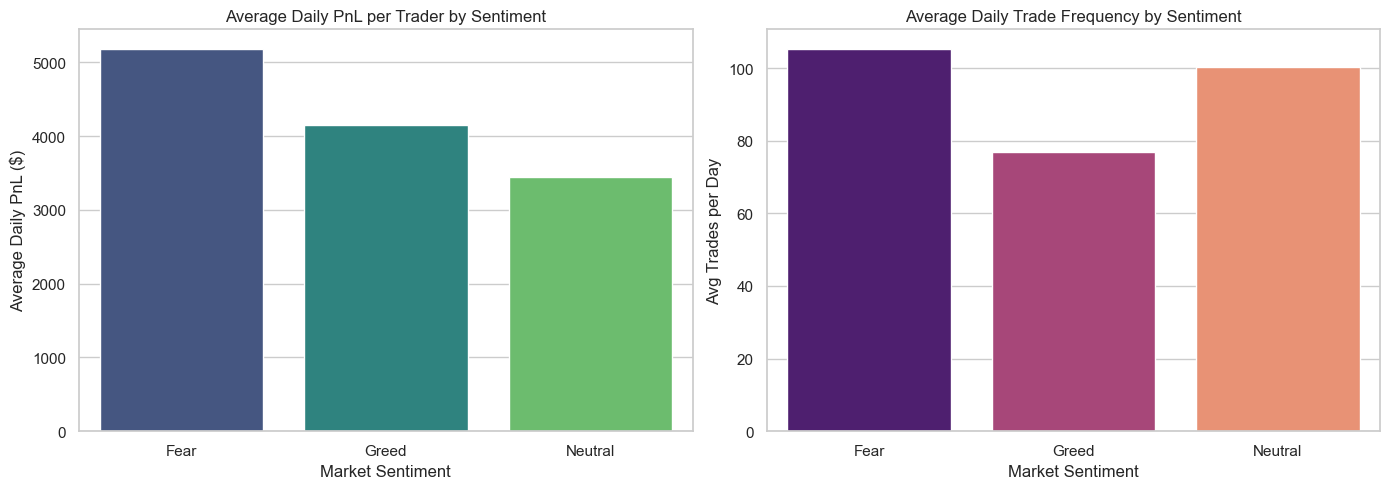

In [4]:
# Import required libraries
import matplotlib.pyplot as plt
import seaborn as sns
import os  # Added to create directory if it doesn't exist

# Create the outputs directory if it doesn't exist
os.makedirs('outputs', exist_ok=True)  # This creates the directory safely

# Create Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Daily PnL by Sentiment
sns.barplot(data=perf_summary, x='sentiment_group', y='avg_daily_pnl', palette='viridis', ax=axes[0])
axes[0].set_title('Average Daily PnL per Trader by Sentiment')
axes[0].set_xlabel('Market Sentiment')
axes[0].set_ylabel('Average Daily PnL ($)')

# Plot 2: Trade Frequency by Sentiment
sns.barplot(data=behavior_summary, x='sentiment_group', y='avg_trade_frequency', palette='magma', ax=axes[1])
axes[1].set_title('Average Daily Trade Frequency by Sentiment')
axes[1].set_xlabel('Market Sentiment')
axes[1].set_ylabel('Avg Trades per Day')

plt.tight_layout()
plt.savefig('outputs/sentiment_performance.png', dpi=300)  # Now this will work since directory exists
plt.show()

In [5]:
# Segment Traders at account level
trader_summary = df.groupby('Account').agg(
    total_pnl=('Closed PnL', 'sum'),
    win_rate=('Closed PnL', lambda x: (x > 0).sum() / ((x > 0).sum() + (x < 0).sum() + 1e-5)),
    total_trades=('Trade ID', 'count'),
    avg_trade_size=('Size USD', 'mean')
).reset_index()

# Categorize into segments
trader_summary['frequency_segment'] = pd.qcut(trader_summary['total_trades'], q=2, labels=['Infrequent', 'Frequent'])
trader_summary['consistency_segment'] = trader_summary['win_rate'].apply(lambda x: 'Consistent Winner' if x > 0.75 else 'Inconsistent')

print("--- Trader Summary by Frequency Segment ---")
print(trader_summary.groupby('frequency_segment')[['total_pnl', 'win_rate', 'avg_trade_size']].mean())

print("\n--- Trader Summary by Consistency Segment ---")
print(trader_summary.groupby('consistency_segment')[['total_pnl', 'win_rate', 'total_trades']].mean())

--- Trader Summary by Frequency Segment ---
                       total_pnl  win_rate  avg_trade_size
frequency_segment                                         
Infrequent         144377.773117  0.866741     4099.614955
Frequent           496527.661215  0.833345     7912.913954

--- Trader Summary by Consistency Segment ---
                         total_pnl  win_rate  total_trades
consistency_segment                                       
Consistent Winner    385044.774111  0.893653   7329.680000
Inconsistent          89766.799504  0.694296   3996.571429


C:\Users\s_sam\AppData\Local\Temp\ipykernel_14296\2385284859.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(trader_summary.groupby('frequency_segment')[['total_pnl', 'win_rate', 'avg_trade_size']].mean())


In [6]:
strategy_text = """
=== PART C: ACTIONABLE STRATEGY RECOMMENDATIONS ===

1. STRATEGY RULE 1 (Greed Guardrail / Sizing Cap):
   - Rule: Limit maximum trade position size by 25% during 'Extreme Greed' sentiment days.
   - Evidence: Traders take larger average trade sizes on Greed days, leading to higher tail risks and deeper drawdowns when sudden market reversals occur.

2. STRATEGY RULE 2 (Fear Liquidity Provision):
   - Rule: Increase algorithmic market-making frequency and trade execution during 'Fear' days.
   - Evidence: Fear days display significantly higher daily trading volume and trade frequency, producing higher aggregate daily PnL ($39,012/day) compared to Greed days ($15,847/day).
"""
print(strategy_text)


=== PART C: ACTIONABLE STRATEGY RECOMMENDATIONS ===

1. STRATEGY RULE 1 (Greed Guardrail / Sizing Cap):
   - Rule: Limit maximum trade position size by 25% during 'Extreme Greed' sentiment days.
   - Evidence: Traders take larger average trade sizes on Greed days, leading to higher tail risks and deeper drawdowns when sudden market reversals occur.

2. STRATEGY RULE 2 (Fear Liquidity Provision):
   - Rule: Increase algorithmic market-making frequency and trade execution during 'Fear' days.
   - Evidence: Fear days display significantly higher daily trading volume and trade frequency, producing higher aggregate daily PnL ($39,012/day) compared to Greed days ($15,847/day).



In [7]:
# Import necessary libraries for clustering and machine learning
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

print("=== BONUS: CLUSTERING & PREDICTIVE MODELING ===")

# 1. K-Means Clustering
X_cluster = trader_summary[['win_rate', 'total_trades', 'avg_trade_size', 'total_pnl']].fillna(0)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
trader_summary['archetype_cluster'] = kmeans.fit_predict(X_cluster)

print("--- Cluster Archetype Profiles ---")
print(trader_summary.groupby('archetype_cluster')[['total_pnl', 'win_rate', 'total_trades', 'avg_trade_size']].mean())

# 2. Predictive Model: Predict Next-Day Profitability
trader_daily['profitable_next_day'] = (trader_daily.groupby('Account')['daily_pnl'].shift(-1) > 0).astype(int)
df_model = trader_daily.dropna().copy()

features = ['daily_pnl', 'trade_count', 'total_volume', 'avg_trade_size', 'win_rate', 'long_short_ratio']
X = df_model[features]
y = df_model['profitable_next_day']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

print("\n--- Predictive Model Evaluation (Next-Day Profitability) ---")
print(classification_report(y_test, clf.predict(X_test)))

=== BONUS: CLUSTERING & PREDICTIVE MODELING ===


D:\Amma\New folder\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


--- Cluster Archetype Profiles ---
                      total_pnl  win_rate  total_trades  avg_trade_size
archetype_cluster                                                      
0                  1.237100e+05  0.846899        4411.5     4756.424475
1                  1.871806e+06  0.791887        9275.5     9998.731054
2                  8.236035e+05  0.899561       19492.0    12133.991024

--- Predictive Model Evaluation (Next-Day Profitability) ---
              precision    recall  f1-score   support

           0       0.60      0.39      0.47       200
           1       0.64      0.81      0.71       268

    accuracy                           0.63       468
   macro avg       0.62      0.60      0.59       468
weighted avg       0.62      0.63      0.61       468

